In [1]:
import pandas as pd

# Load the uploaded Excel file to check its structure
file_path = '../dataset/rab94row.xlsx'
data = pd.read_excel(file_path)

# Display the first few rows to understand the structure
data.head()

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi
0,Gedung Apartemen,871000000000,606,DKI Jakarta,2021,68204.25309,6,120.020872,31,121.42,109.64,1.53
1,Gedung Apartemen,876000000000,605,DKI Jakarta,2021,68590.48909,6,120.617753,31,121.42,109.64,1.53
2,Gedung Apartemen,936000000000,649,DKI Jakarta,2020,73232.95902,6,128.564830,33,116.84,103.68,1.59
3,Gedung Apartemen,938000000000,628,DKI Jakarta,2020,73318.17099,6,128.882451,33,116.84,103.68,1.59
4,Gedung Apartemen,1050000000000,668,DKI Jakarta,2020,81640.56895,6,142.594757,36,116.84,103.68,1.59


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import BayesianRidge, Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [3]:
# Label encoding kolom 'Provinsi' dan nama proyek karena nilainya kategorikal
label_encoder = LabelEncoder()
data['label_provinsi'] = label_encoder.fit_transform(data['provinsi'])
data['label_namaproyek'] = label_encoder.fit_transform(data['namaproyek'])

# Melihat nilai unik dari hasil encoding kolom 'provinsi_encoded'
provinsi_unik = data[['provinsi', 'label_provinsi']].drop_duplicates().sort_values(
    by='label_provinsi')

# Melihat nilai unik dari hasil encoding kolom 'namaproyek_encoded'
namaproyek_unik = data[['namaproyek', 'label_namaproyek']].drop_duplicates().sort_values(
    by='label_namaproyek')

In [4]:
data.corr(numeric_only=True)

,rab,waktu,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi,label_provinsi,label_namaproyek
rab,1.000000,0.982262,-0.090441,0.999900,0.328408,0.996631,0.996013,0.041004,0.056369,0.055564,-0.034124,NaN
waktu,0.982262,1.000000,-0.115240,0.982144,0.263061,0.986283,0.982037,0.037824,0.087599,0.063666,-0.029806,NaN
tahun,-0.090441,-0.115240,1.000000,-0.090192,0.001342,-0.095553,-0.084871,-0.139272,-0.521197,0.083498,0.121568,NaN
luas,0.999900,0.982144,-0.090192,1.000000,0.327254,0.996939,0.996022,0.042075,0.055080,0.052929,-0.036005,NaN
subitem,0.328408,0.263061,0.001342,0.327254,1.000000,0.279291,0.277861,-0.135471,-0.068469,-0.084792,-0.134421,NaN
tinggi,0.996631,0.986283,-0.095553,0.996939,0.279291,1.000000,0.997575,0.062180,0.061185,0.050301,-0.035330,NaN
lantai,0.996013,0.982037,-0.084871,0.996022,0.277861,0.997575,1.000000,0.064248,0.049017,0.045683,-0.030228,NaN
ikk,0.041004,0.037824,-0.139272,0.042075,-0.135471,0.062180,0.064248,1.000000,0.077721,-0.127792,-0.298932,NaN
ihbp,0.056369,0.087599,-0.521197,0.055080,-0.068469,0.061185,0.049017,0.077721,1.000000,0.307840,0.057543,NaN
inflasi,0.055564,0.063666,0.083498,0.052929,-0.084792,0.050301,0.045683,-0.127792,0.307840,1.000000,0.493391,NaN


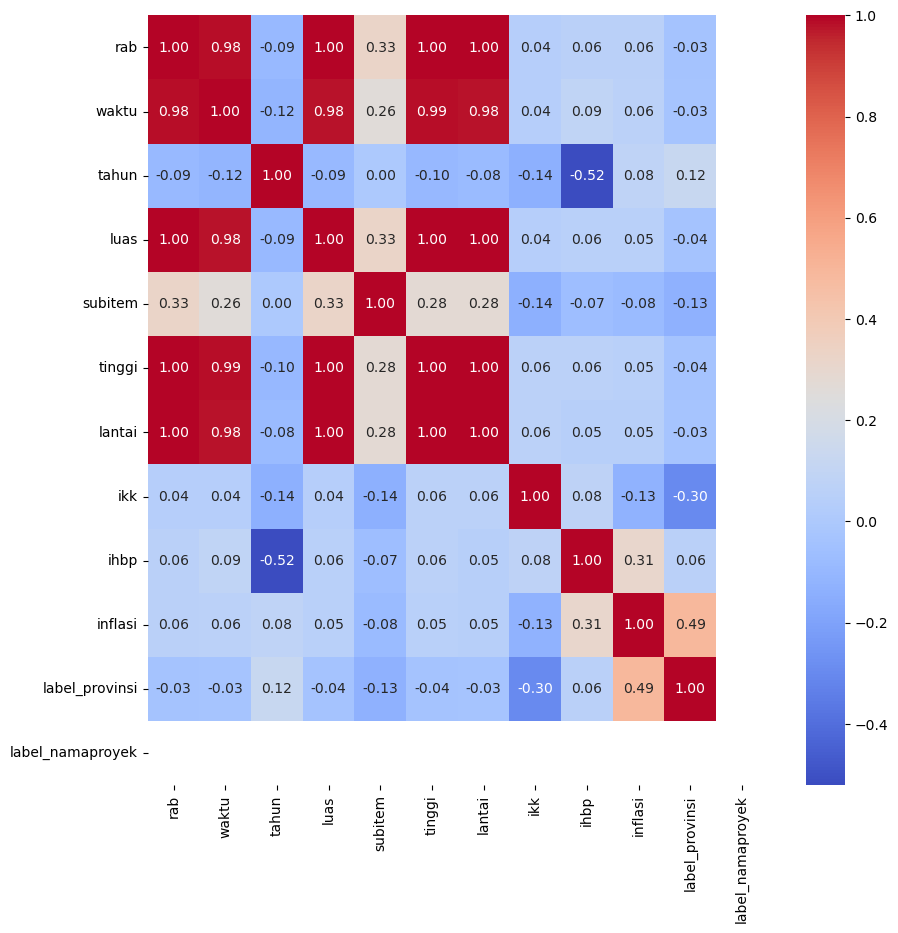

In [5]:
# Digunakan untuk membuat visualisasi dalam bentuk grafik atau plot
import seaborn as sns
import matplotlib.pyplot as plt
# Visualisasi korelasi antar fitur atau kolom apakah saling berpengaruh atau tidak
fig, ax = plt.subplots(figsize=(10,10))  
sns.heatmap(data.corr(numeric_only=True), 
            annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
plt.show()

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   namaproyek        94 non-null     object 
 1   rab               94 non-null     int64  
 2   waktu             94 non-null     int64  
 3   provinsi          94 non-null     object 
 4   tahun             94 non-null     int64  
 5   luas              94 non-null     float64
 6   subitem           94 non-null     int64  
 7   tinggi            94 non-null     float64
 8   lantai            94 non-null     int64  
 9   ikk               94 non-null     float64
 10  ihbp              94 non-null     float64
 11  inflasi           94 non-null     float64
 12  label_provinsi    94 non-null     int32  
 13  label_namaproyek  94 non-null     int32  
dtypes: float64(5), int32(2), int64(5), object(2)
memory usage: 9.7+ KB


In [7]:
cekduplikat = data[data.duplicated()]
cekduplikat

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi,label_provinsi,label_namaproyek


In [8]:
data = data.drop_duplicates()

cekduplikat = data[data.duplicated()]
cekduplikat, data.shape

(Empty DataFrame
 Columns: [namaproyek, rab, waktu, provinsi, tahun, luas, subitem, tinggi, lantai, ikk, ihbp, inflasi, label_provinsi, label_namaproyek]
 Index: [],
 (94, 14))

In [10]:
# Identifikasi kolom numerik untuk analisis outlier
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Fungsi untuk mendeteksi outlier menggunakan metode IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analisis outlier untuk setiap kolom numerik
outlier_results = {}
for col in numerical_columns:
    outliers, lower, upper = detect_outliers_iqr(data, col)
    outlier_results[col] = {
        "outliers_count": len(outliers),
        "lower_bound": lower,
        "upper_bound": upper
    }

# Menampilkan hasil analisis outlier
outlier_results

{'rab': {'outliers_count': 5,
  'lower_bound': 606875000000.0,
  'upper_bound': 1363875000000.0},
 'waktu': {'outliers_count': 2,
  'lower_bound': 520.125,
  'upper_bound': 771.125},
 'tahun': {'outliers_count': 0, 'lower_bound': 2013.0, 'upper_bound': 2029.0},
 'luas': {'outliers_count': 5,
  'lower_bound': 48417.69127874997,
  'upper_bound': 105433.86764875002},
 'subitem': {'outliers_count': 1, 'lower_bound': 6.0, 'upper_bound': 6.0},
 'tinggi': {'outliers_count': 5,
  'lower_bound': 88.87272966249998,
  'upper_bound': 178.28928076250003},
 'lantai': {'outliers_count': 2, 'lower_bound': 22.0, 'upper_bound': 46.0},
 'ikk': {'outliers_count': 0,
  'lower_bound': 84.69625,
  'upper_bound': 133.58625},
 'ihbp': {'outliers_count': 0,
  'lower_bound': 53.27000000000002,
  'upper_bound': 197.98999999999998},
 'inflasi': {'outliers_count': 7,
  'lower_bound': 0.6050000000000004,
  'upper_bound': 4.805}}

In [11]:
# Identifikasi kolom numerik untuk analisis outlier
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Fungsi untuk mendeteksi dan menghapus baris yang mengandung outlier
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hapus baris yang memiliki nilai outlier
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Hapus outlier untuk setiap kolom numerik
data_cleaned = data.copy()
for col in numerical_columns:
    data_cleaned = remove_outliers_iqr(data_cleaned, col)

In [12]:
data_cleaned.shape

(80, 14)

In [13]:
# Split data into features and target
X1 = data_cleaned.drop(columns=['rab', 'namaproyek', 'provinsi'])
y1 = data_cleaned['rab']

# Split into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, 
    test_size=0.3, 
    random_state=42)

# Split into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X1, y1, 
    test_size=0.2, 
    random_state=42)



In [19]:
# Initialize models
models = {
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Bayesian Ridge': BayesianRidge(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN Regressor': KNeighborsRegressor(),
    'Lasso Regression': Lasso(random_state=42),
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Ridge Regression': Ridge(random_state=42),
    'SVR': SVR(),
    'XGBoost': xgb.XGBRegressor(random_state=42)
}

# 70:30
# Train and evaluate each model with additional metrics
results1 = []
for name1, model1 in models.items():
    # Fit model to training data
    model1.fit(X_train1, y_train1)
    
    # Predict on training data
    y_train_pred1 = model1.predict(X_train1)
    
    # Predict on testing data
    y_pred1 = model1.predict(X_test1)
    
    # Calculate metrics for training data
    r2_train1 = r2_score(y_train1, y_train_pred1)
    
    # Calculate metrics for testing data
    mse1 = mean_squared_error(y_test1, y_pred1)
    mae1 = mean_absolute_error(y_test1, y_pred1)
    r21 = r2_score(y_test1, y_pred1)
    
    # Append results
    results1.append({
        'Model': name1,
        'Training R2 Score': r2_train1,
        'Testing RMSE': np.sqrt(mse1),
        'Testing MAE': mae1,
        'Testing R2 Score': r21
    })

# Convert results into a DataFrame for better visualization
results_df1 = pd.DataFrame(results1).sort_values(by='Testing R2 Score', ascending=False)

# 80:20
# Train and evaluate each model with additional metrics
results2 = []
for name2, model2 in models.items():
    # Fit model to training data
    model2.fit(X_train2, y_train2)
    
    # Predict on training data
    y_train_pred2 = model2.predict(X_train2)
    
    # Predict on testing data
    y_pred2 = model2.predict(X_test2)
    
    # Calculate metrics for training data
    r2_train2 = r2_score(y_train2, y_train_pred2)
    
    # Calculate metrics for testing data
    mse2 = mean_squared_error(y_test2, y_pred2)
    mae2 = mean_absolute_error(y_test2, y_pred2)
    r22 = r2_score(y_test2, y_pred2)
    
    # Append results
    results2.append({
        'Model': name2,
        'Training R2 Score': r2_train2,
        'Testing RMSE': np.sqrt(mse2),
        'Testing MAE': mae2,
        'Testing R2 Score': r22
    })

# Convert results into a DataFrame for better visualization
results_df2 = pd.DataFrame(results2).sort_values(by='Testing R2 Score', ascending=False)


c:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.305e+19, tolerance: 5.908e+19
  model = cd_fast.enet_coordinate_descent(
c:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.019e+20, tolerance: 6.346e+19
  model = cd_fast.enet_coordinate_descent(


In [20]:
results_df1

,Model,Training R2 Score,Testing RMSE,Testing MAE,Testing R2 Score
8,Ridge Regression,9.997145e-01,1.780383e+09,1.291609e+09,0.999602
6,Linear Regression,9.997189e-01,1.905044e+09,1.327626e+09,0.999544
5,Lasso Regression,9.997189e-01,1.908053e+09,1.329686e+09,0.999543
3,Gradient Boosting,1.000000e+00,6.074136e+09,3.441130e+09,0.995368
2,Decision Tree,1.000000e+00,6.254998e+09,3.875000e+09,0.995088
7,Random Forest,9.989386e-01,6.328755e+09,3.754583e+09,0.994972
10,XGBoost,1.000000e+00,6.363354e+09,4.204463e+09,0.994916
0,AdaBoost,9.979834e-01,7.087787e+09,5.177183e+09,0.993693
4,KNN Regressor,9.948248e-01,9.339789e+09,4.125000e+09,0.989048
9,SVR,-1.175340e-01,8.934950e+10,6.279167e+10,-0.002268


Hasil 80:20

In [21]:
results_df2

,Model,Training R2 Score,Testing RMSE,Testing MAE,Testing R2 Score
8,Ridge Regression,9.996761e-01,1.393243e+09,1.132548e+09,0.999801
6,Linear Regression,9.996790e-01,1.520080e+09,1.192354e+09,0.999764
5,Lasso Regression,9.996790e-01,1.521567e+09,1.193076e+09,0.999763
10,XGBoost,1.000000e+00,4.782371e+09,3.515380e+09,0.997661
3,Gradient Boosting,1.000000e+00,5.289620e+09,2.942021e+09,0.997138
7,Random Forest,9.990779e-01,5.517950e+09,3.409375e+09,0.996886
0,AdaBoost,9.977422e-01,6.190802e+09,4.125797e+09,0.996080
2,Decision Tree,1.000000e+00,7.909646e+09,4.687500e+09,0.993601
4,KNN Regressor,9.950954e-01,1.097873e+10,4.912500e+09,0.987671
9,SVR,-9.468939e-02,9.912870e+10,6.725000e+10,-0.005102
